# Laboratorio 10 - Búsqueda Eficiente con PgVector

## P0 a P2: Carga del dataset, generación de embeddings y búsqueda kNN lineal

Este notebook desarrolla:

- **P0:** Cargar el dataset de rostros LFW.
- **P1:** Generar embeddings faciales de 128 dimensiones con `face_recognition`.
- **P2:** Realizar búsqueda kNN lineal usando distancia euclidiana `<->` y distancia coseno `<=>`.


## Requisitos previos

Antes de ejecutar este notebook, asegúrate de haber creado el entorno Conda:

```bash
conda create -n vision python=3.9
conda activate vision
conda install -c conda-forge dlib
conda install -c conda-forge face_recognition
pip install pandas numpy matplotlib psycopg2-binary pgvector jupyter
```

Además, el contenedor de PostgreSQL con pgvector debe estar activo:

```bash
docker start pgvector
```

Si todavía no existe el contenedor:

```bash
docker run -d --name pgvector -e POSTGRES_PASSWORD=123456 -p 5433:5432 ankane/pgvector
```


# P0. Cargar el Dataset de Rostros

La ruta del dataset debe apuntar a la carpeta que contiene las subcarpetas de personas.

En tu caso, la ruta es:

```text
C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled
```


In [1]:
import os
import glob
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ruta del dataset LFW
DATASET_PATH = r"C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled"


In [2]:
def cargar_coleccion(dataset_path):
    """
    Carga todas las imágenes .jpg del dataset LFW.
    Retorna un DataFrame con columnas: person y path.
    """
    coleccion = []

    for path in glob.iglob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True):
        person = Path(path).parent.name
        coleccion.append({
            "person": person,
            "path": path
        })

    return pd.DataFrame(coleccion)


coleccion = cargar_coleccion(DATASET_PATH)

print("Cantidad de imágenes cargadas:", len(coleccion))
coleccion.head(10)


Cantidad de imágenes cargadas: 13233


,person,path
0,Aaron_Eckhart,C:\Users\josue\Downloads\archive (1)\lfw-funne...
1,Aaron_Guiel,C:\Users\josue\Downloads\archive (1)\lfw-funne...
2,Aaron_Patterson,C:\Users\josue\Downloads\archive (1)\lfw-funne...
3,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
4,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
5,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
6,Aaron_Peirsol,C:\Users\josue\Downloads\archive (1)\lfw-funne...
7,Aaron_Pena,C:\Users\josue\Downloads\archive (1)\lfw-funne...
8,Aaron_Sorkin,C:\Users\josue\Downloads\archive (1)\lfw-funne...
9,Aaron_Sorkin,C:\Users\josue\Downloads\archive (1)\lfw-funne...


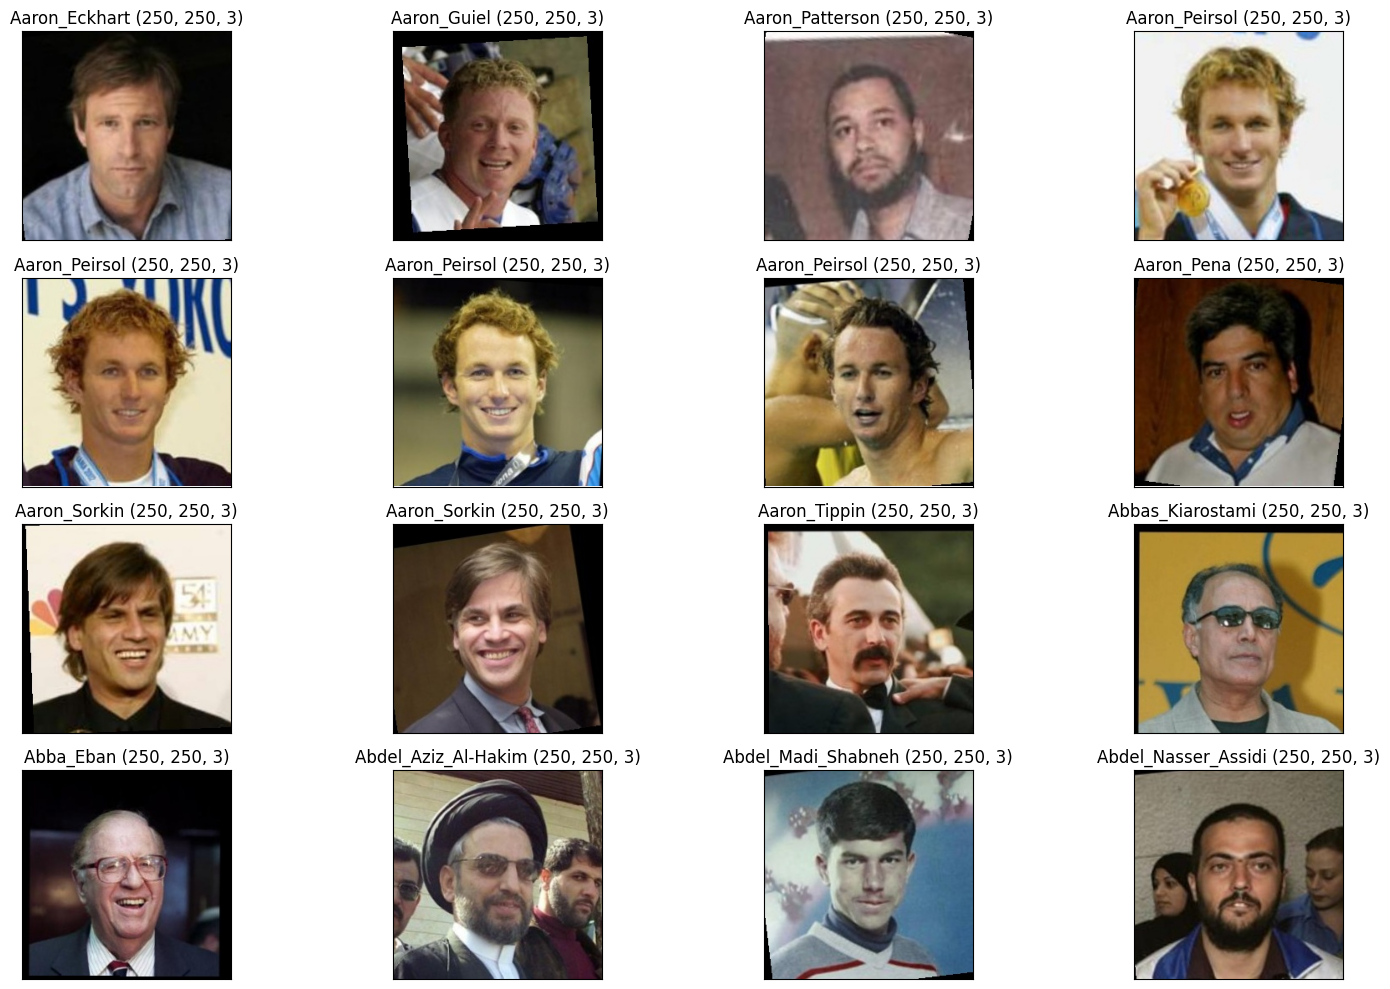

In [3]:
def mostrar_fotos(coleccion, posiciones):
    """
    Muestra imágenes del dataset según posiciones dadas.
    """
    plt.figure(figsize=(16, 10))

    for i, idx in enumerate(posiciones):
        img = plt.imread(coleccion.path.iloc[idx])

        plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{coleccion.person.iloc[idx]} {img.shape}")
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()


mostrar_fotos(coleccion, list(range(16)))


# P1. Generar vectores característicos

Cada imagen se procesa con `face_recognition`. Si se detecta rostro, se extrae el primer embedding facial. Cada embedding tiene **128 dimensiones**.


## Crear tabla en PostgreSQL

Antes de guardar los embeddings, ejecuta esto en pgAdmin sobre la base `postgres` del contenedor `pgvector`:

```sql
CREATE EXTENSION IF NOT EXISTS vector;

DROP TABLE IF EXISTS face_embeddings;

CREATE TABLE face_embeddings (
    id SERIAL PRIMARY KEY,
    name TEXT,
    path TEXT,
    embedding VECTOR(128)
);
```


In [4]:
import face_recognition
import psycopg2
from pgvector.psycopg2 import register_vector

DB_CONFIG = {
    "host": "localhost",
    "port": 5433,
    "database": "postgres",
    "user": "postgres",
    "password": "123456"
}


def conectar_db():
    """
    Conecta Python con PostgreSQL y registra el tipo vector.
    """
    conn = psycopg2.connect(**DB_CONFIG)
    register_vector(conn)
    return conn


c:\Users\josue\miniconda3\envs\vision\lib\site-packages\face_recognition_models\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [5]:
def generate_face_embeddings(coleccion, n):
    """
    Genera embeddings faciales para las primeras N imágenes de la colección.
    """
    resultados = []
    limite = min(n, len(coleccion))

    for i in range(limite):
        person = coleccion.iloc[i]["person"]
        filename = coleccion.iloc[i]["path"]

        try:
            image = face_recognition.load_image_file(filename)
            face_encodings = face_recognition.face_encodings(image)

            if face_encodings:
                embedding = face_encodings[0]

                resultados.append({
                    "name": person,
                    "path": filename,
                    "embedding": embedding
                })

                print(f"[OK] {i + 1}/{limite} - {person}")
            else:
                print(f"[SIN ROSTRO] {i + 1}/{limite} - {filename}")

        except Exception as e:
            print(f"[ERROR] {filename}: {e}")

    return resultados


In [6]:
def guardar_embeddings_postgres(embeddings):
    """
    Guarda los embeddings en PostgreSQL.
    """
    conn = conectar_db()
    cur = conn.cursor()

    for item in embeddings:
        cur.execute(
            """
            INSERT INTO face_embeddings (name, path, embedding)
            VALUES (%s, %s, %s)
            """,
            (
                item["name"],
                item["path"],
                item["embedding"].tolist()
            )
        )

    conn.commit()
    cur.close()
    conn.close()

    print("Embeddings guardados correctamente en PostgreSQL.")


## Ejecutar generación de embeddings

Para probar rápido, usa `N = 100`. Para el entregable puedes usar `N = 1000` o más, según el tiempo disponible.


In [7]:
N = 1000

embeddings = generate_face_embeddings(coleccion, N)
print("Cantidad de embeddings generados:", len(embeddings))

guardar_embeddings_postgres(embeddings)


[OK] 1/1000 - Aaron_Eckhart
[OK] 2/1000 - Aaron_Guiel
[OK] 3/1000 - Aaron_Patterson
[OK] 4/1000 - Aaron_Peirsol
[OK] 5/1000 - Aaron_Peirsol
[OK] 6/1000 - Aaron_Peirsol
[OK] 7/1000 - Aaron_Peirsol
[OK] 8/1000 - Aaron_Pena
[OK] 9/1000 - Aaron_Sorkin
[OK] 10/1000 - Aaron_Sorkin
[OK] 11/1000 - Aaron_Tippin
[OK] 12/1000 - Abbas_Kiarostami
[OK] 13/1000 - Abba_Eban
[OK] 14/1000 - Abdel_Aziz_Al-Hakim
[OK] 15/1000 - Abdel_Madi_Shabneh
[OK] 16/1000 - Abdel_Nasser_Assidi
[OK] 17/1000 - Abdel_Nasser_Assidi
[OK] 18/1000 - Abdoulaye_Wade
[OK] 19/1000 - Abdoulaye_Wade
[SIN ROSTRO] 20/1000 - C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Abdoulaye_Wade\Abdoulaye_Wade_0003.jpg
[OK] 21/1000 - Abdoulaye_Wade
[OK] 22/1000 - Abdulaziz_Kamilov
[OK] 23/1000 - Abdullah
[OK] 24/1000 - Abdullah
[OK] 25/1000 - Abdullah
[OK] 26/1000 - Abdullah
[OK] 27/1000 - Abdullah_Ahmad_Badawi
[OK] 28/1000 - Abdullah_al-Attiyah
[OK] 29/1000 - Abdullah_al-Attiyah
[OK] 30/1000 - Abdullah_al-Attiyah
[OK] 31/1000 -

## Verificar embeddings guardados

Esta consulta comprueba cuántos embeddings se guardaron y que cada vector tenga 128 dimensiones.


In [8]:
conn = conectar_db()
cur = conn.cursor()

cur.execute("SELECT COUNT(*) FROM face_embeddings;")
print("Total de embeddings en PostgreSQL:", cur.fetchone()[0])

cur.execute("SELECT id, name, path, vector_dims(embedding) FROM face_embeddings LIMIT 10;")
for row in cur.fetchall():
    print(row)

cur.close()
conn.close()


Total de embeddings en PostgreSQL: 993
(1, 'Aaron_Eckhart', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Eckhart\\Aaron_Eckhart_0001.jpg', 128)
(2, 'Aaron_Guiel', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Guiel\\Aaron_Guiel_0001.jpg', 128)
(3, 'Aaron_Patterson', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Patterson\\Aaron_Patterson_0001.jpg', 128)
(4, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0001.jpg', 128)
(5, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0002.jpg', 128)
(6, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0003.jpg', 128)
(7, 'Aaron_Peirsol', 'C:\\Users\\josue\\Downloads\\archive (1)\\lfw-funneled\\lfw_funneled\\Aaron_Peirsol\\Aaron_Peirsol_0004.jpg', 128)
(8

# P2. Búsqueda kNN Lineal

En esta parte no se usan índices. La consulta compara el embedding de entrada con todos los embeddings guardados en la tabla.

Se usan dos distancias:

- Distancia euclidiana: `<->`
- Distancia coseno: `<=>`

Coloca una imagen de consulta fuera del dataset, por ejemplo:

```text
C:\Users\josue\Downloads\consulta.jpg
```


In [ ]:
import time

# Cambia esta ruta por tu imagen de consulta real
QUERY_IMAGE = r"C:\Users\josue\Downloads\consulta.jpg.jpeg"


def obtener_embedding_consulta(image_path):
    """
    Extrae el embedding facial de una imagen de consulta.
    """
    image = face_recognition.load_image_file(image_path)
    face_encodings = face_recognition.face_encodings(image)

    if not face_encodings:
        raise ValueError("No se detectó ningún rostro en la imagen de consulta.")

    return face_encodings[0]


In [14]:
def knn_lineal_euclidiana(query_embedding, k=5):
    """
    Búsqueda kNN lineal usando distancia euclidiana.
    Operador pgvector: <->
    """
    conn = conectar_db()
    cur = conn.cursor()

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <-> %s AS distance
        FROM face_embeddings
        ORDER BY embedding <-> %s
        LIMIT %s;
        """,
        (
            query_embedding.tolist(),
            query_embedding.tolist(),
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start


def knn_lineal_coseno(query_embedding, k=5):
    """
    Búsqueda kNN lineal usando distancia coseno.
    Operador pgvector: <=>
    """
    conn = conectar_db()
    cur = conn.cursor()

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <=> %s AS distance
        FROM face_embeddings
        ORDER BY embedding <=> %s
        LIMIT %s;
        """,
        (
            query_embedding.tolist(),
            query_embedding.tolist(),
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start


In [17]:
import os

QUERY_IMAGE = r"C:\Users\josue\Downloads\consulta.jpg.jpeg"

print("Ruta usada:", QUERY_IMAGE)
print("Existe:", os.path.exists(QUERY_IMAGE))

Ruta usada: C:\Users\josue\Downloads\consulta.jpg.jpeg
Existe: True


In [19]:
def embedding_to_pgvector(embedding):
    """
    Convierte un embedding numpy array a formato string compatible con pgvector.
    Ejemplo: [0.1,0.2,0.3,...]
    """
    return "[" + ",".join(map(str, embedding.tolist())) + "]"


def knn_lineal_euclidiana(query_embedding, k=5):
    """
    Búsqueda kNN lineal usando distancia euclidiana.
    Operador pgvector: <->
    """
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <-> %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding <-> %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start


def knn_lineal_coseno(query_embedding, k=5):
    """
    Búsqueda kNN lineal usando distancia coseno.
    Operador pgvector: <=>
    """
    conn = conectar_db()
    cur = conn.cursor()

    query_vector = embedding_to_pgvector(query_embedding)

    start = time.time()

    cur.execute(
        """
        SELECT 
            id,
            name,
            path,
            embedding <=> %s::vector AS distance
        FROM face_embeddings
        ORDER BY embedding <=> %s::vector
        LIMIT %s;
        """,
        (
            query_vector,
            query_vector,
            k
        )
    )

    resultados = cur.fetchall()
    end = time.time()

    cur.close()
    conn.close()

    return resultados, end - start

In [20]:
K = 5

query_embedding = obtener_embedding_consulta(QUERY_IMAGE)

resultados_euclidiana, tiempo_euclidiana = knn_lineal_euclidiana(query_embedding, K)
resultados_coseno, tiempo_coseno = knn_lineal_coseno(query_embedding, K)

print("===== RESULTADOS KNN LINEAL - DISTANCIA EUCLIDIANA =====")
for r in resultados_euclidiana:
    print(f"ID: {r[0]} | Nombre: {r[1]} | Distancia: {r[3]:.6f} | Path: {r[2]}")

print(f"Tiempo euclidiana: {tiempo_euclidiana:.6f} segundos")

print("\n===== RESULTADOS KNN LINEAL - DISTANCIA COSENO =====")
for r in resultados_coseno:
    print(f"ID: {r[0]} | Nombre: {r[1]} | Distancia: {r[3]:.6f} | Path: {r[2]}")

print(f"Tiempo coseno: {tiempo_coseno:.6f} segundos")

===== RESULTADOS KNN LINEAL - DISTANCIA EUCLIDIANA =====
ID: 267 | Nombre: Alessandra_Cerna | Distancia: 0.495121 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alessandra_Cerna\Alessandra_Cerna_0001.jpg
ID: 62 | Nombre: Abner_Martinez | Distancia: 0.582080 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Abner_Martinez\Abner_Martinez_0001.jpg
ID: 190 | Nombre: Alberto_Gonzales | Distancia: 0.612831 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Alberto_Gonzales\Alberto_Gonzales_0001.jpg
ID: 973 | Nombre: Art_Lopez | Distancia: 0.639620 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Art_Lopez\Art_Lopez_0001.jpg
ID: 894 | Nombre: Armando_Calderon_Sol | Distancia: 0.643291 | Path: C:\Users\josue\Downloads\archive (1)\lfw-funneled\lfw_funneled\Armando_Calderon_Sol\Armando_Calderon_Sol_0001.jpg
Tiempo euclidiana: 0.001442 segundos

===== RESULTADOS KNN LINEAL - DISTANCIA COSENO =====
ID: 267 | Nom

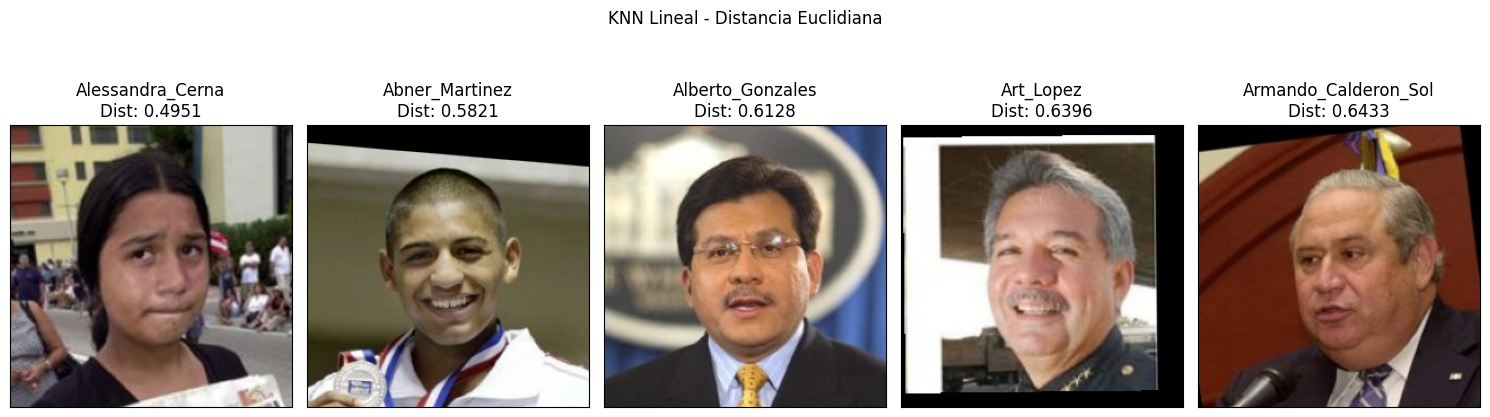

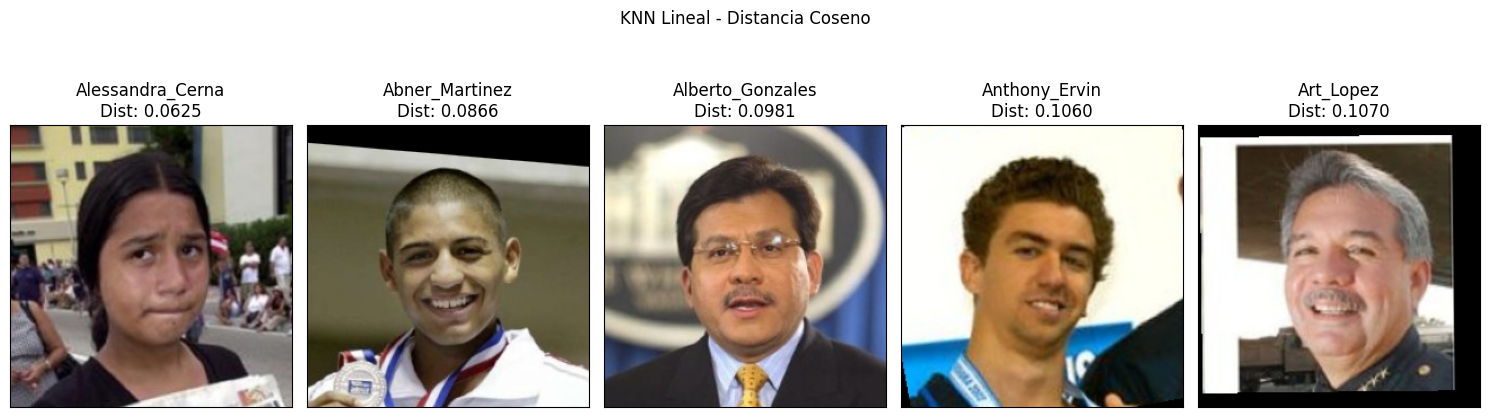

In [22]:
def mostrar_resultados_knn(resultados, titulo):
    """
    Muestra las imágenes recuperadas por kNN.
    """
    plt.figure(figsize=(15, 5))

    for i, r in enumerate(resultados):
        img_path = r[2]
        name = r[1]
        distance = r[3]

        img = plt.imread(img_path)

        plt.subplot(1, len(resultados), i + 1)
        plt.imshow(img)
        plt.title(f"{name}\nDist: {distance:.4f}")
        plt.xticks([])
        plt.yticks([])

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()


mostrar_resultados_knn(resultados_euclidiana, "KNN Lineal - Distancia Euclidiana")
mostrar_resultados_knn(resultados_coseno, "KNN Lineal - Distancia Coseno")


## EXPLAIN ANALYZE

Como en P2 todavía no se usan índices, PostgreSQL debería realizar una búsqueda secuencial o un ordenamiento sobre los resultados calculados.


In [23]:
def explain_analyze_knn(query_embedding, operador="<->", k=5):
    """
    Ejecuta EXPLAIN ANALYZE para revisar el plan de ejecución.
    operador puede ser '<->' o '<=>'.
    """
    conn = conectar_db()
    cur = conn.cursor()

    cur.execute(
        f"""
        EXPLAIN ANALYZE
        SELECT 
            id,
            name,
            path,
            embedding {operador} %s AS distance
        FROM face_embeddings
        ORDER BY embedding {operador} %s
        LIMIT %s;
        """,
        (
            query_embedding.tolist(),
            query_embedding.tolist(),
            k
        )
    )

    plan = cur.fetchall()

    cur.close()
    conn.close()

    for row in plan:
        print(row[0])


print("===== EXPLAIN ANALYZE EUCLIDIANA =====")
explain_analyze_knn(query_embedding, "<->", 5)

print("\n===== EXPLAIN ANALYZE COSENO =====")
explain_analyze_knn(query_embedding, "<=>", 5)


===== EXPLAIN ANALYZE EUCLIDIANA =====


UndefinedFunction: operator does not exist: vector <-> numeric[]
LINE 7:             embedding <-> ARRAY[ -0.09139484912157059,0.1368...
                              ^
HINT:  No operator matches the given name and argument types. You might need to add explicit type casts.


# Análisis P2

En la búsqueda kNN lineal se comparó el embedding de la imagen de consulta contra todos los embeddings almacenados en la tabla `face_embeddings`. Para ello se utilizaron dos métricas proporcionadas por `pgvector`: distancia euclidiana mediante el operador `<->` y distancia coseno mediante el operador `<=>`.

En ambos casos, PostgreSQL debe recorrer la tabla porque todavía no se han creado índices vectoriales. Por esta razón, el tiempo de ejecución depende directamente del número de embeddings almacenados.

Los resultados obtenidos por distancia euclidiana y distancia coseno pueden coincidir o diferir. La distancia euclidiana mide la separación geométrica directa entre dos vectores, mientras que la distancia coseno compara principalmente la orientación entre ellos. Si los embeddings tienen magnitudes similares, los resultados suelen ser parecidos; sin embargo, si existen diferencias en magnitud, el orden del ranking puede cambiar.
